01_Banking_Data_Analytics.ipynb

1. Project Introduction
2. Business Problem
3. Project Objectives
4. Import Libraries
5. Load Banking Datasets
6. Dataset Overview
7. Data Dictionary
8. Data Quality Assessment
9. Exploratory Data Analysis (EDA)
10. Business Insights
11. Conclusion

# AI Banking & Financial Intelligence Platform

## Module 01 : Banking Data Analytics

### Project Description

This project aims to develop an AI-powered Banking and Financial Intelligence Platform using Machine Learning techniques. The first module focuses on understanding and analyzing banking data before building predictive machine learning models.

The datasets include customer information, accounts, loans, transactions, branches, addresses, account types, account statuses, customer types, transaction types, and loan statuses.

This module performs data loading, exploration, profiling, visualization, and preprocessing to prepare the data for future machine learning tasks.

# Business Problem

Banks generate large volumes of customer, transaction, and loan data every day. Before building AI models for fraud detection, loan approval prediction, customer segmentation, and financial analytics, it is essential to understand the data.

Poor data quality can lead to inaccurate machine learning predictions. Therefore, this module focuses on analyzing the data, identifying inconsistencies, handling missing values, and preparing high-quality datasets.

# Objectives

• Load all banking datasets

• Understand the structure of each dataset

• Perform data profiling

• Detect missing values

• Detect duplicate records

• Analyze numerical and categorical features

• Visualize important business information

• Prepare the data for Machine Learning

In [1]:
# ==========================================================
# MODULE 01 : IMPORT LIBRARIES
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("="*60)
print("All Libraries Imported Successfully")
print("="*60)

All Libraries Imported Successfully


# Load Banking Datasets

modules/
    Module_01_Data_Analytics/
        notebook/

datasets/raw/

        

In [2]:
from pathlib import Path

# Project root (three levels up from notebook/)
project_root = Path.cwd().parents[2]

data_path = project_root/"AI_Banking_Financial_Intelligence"/ "datasets" / "raw"

print(data_path)

/home/student/308/mlm/AI_Banking_Financial_Intelligence/datasets/raw


In [3]:
accounts = pd.read_csv(data_path / "accounts.csv")
customers = pd.read_csv(data_path / "customers.csv")
transactions = pd.read_csv(data_path / "transactions.csv")
loans = pd.read_csv(data_path / "loans.csv")
branches = pd.read_csv(data_path / "branches.csv")
addresses = pd.read_csv(data_path / "addresses.csv")

account_types = pd.read_csv(data_path / "account_types.csv")
account_statuses = pd.read_csv(data_path / "account_statuses.csv")
customer_types = pd.read_csv(data_path / "customer_types.csv")
loan_statuses = pd.read_csv(data_path / "loan_statuses.csv")
transaction_types = pd.read_csv(data_path / "transaction_types.csv")

print("All datasets loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/home/student/308/mlm/AI_Banking_Financial_Intelligence/datasets/raw/accounts.csv'

In [ ]:
datasets = {
    "Customers": customers,
    "Accounts": accounts,
    "Transactions": transactions,
    "Loans": loans,
    "Branches": branches,
    "Addresses": addresses,
    "Account Types": account_types,
    "Account Status": account_statuses,
    "Customer Types": customer_types,
    "Loan Status": loan_statuses,
    "Transaction Types": transaction_types
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

# Dataset Profiling

The objective of this section is to understand the structure and quality of each banking dataset before performing exploratory data analysis and machine learning.


In [ ]:
def profile_dataset(df, name):
    print("=" * 80)
    print(f"DATASET : {name}")
    print("=" * 80)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nMemory Usage")
    print(df.memory_usage(deep=True))

    print("\nFirst Five Rows")
    display(df.head())

    print("\nLast Five Rows")
    display(df.tail())

In [ ]:
for name, df in datasets.items():
    profile_dataset(df, name)

# Statistical Summary

In [ ]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.describe())

In [ ]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    display(df.describe(include="object"))

# Missing Value Analysis

In [ ]:
missing_report = []

for name, df in datasets.items():

    total_missing = df.isnull().sum().sum()

    missing_report.append({
        "Dataset": name,
        "Total Missing Values": total_missing
    })

missing_report = pd.DataFrame(missing_report)

missing_report

In [ ]:
for name, df in datasets.items():

    print(name)
    print("="*80)
    msno.matrix(df)

    plt.show()

# Duplicate Record Analysis

In [ ]:
duplicate_report = []

for name, df in datasets.items():

    duplicate_report.append({
        "Dataset": name,
        "Duplicate Rows": df.duplicated().sum()
    })

duplicate_report = pd.DataFrame(duplicate_report)

duplicate_report

# Data Quality Summary

In [ ]:
quality = []

for name, df in datasets.items():

    quality.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

quality = pd.DataFrame(quality)

quality

# Data Dictionary

The following table describes the datasets used in this project.

In [ ]:
dictionary = pd.DataFrame({

    "Dataset":[
        "Customers",
        "Accounts",
        "Transactions",
        "Loans",
        "Branches",
        "Addresses",
        "Account Types",
        "Account Statuses",
        "Customer Types",
        "Loan Statuses",
        "Transaction Types"
    ],

    "Purpose":[
        "Stores customer information",
        "Stores customer bank account information",
        "Stores transaction history",
        "Stores loan information",
        "Stores branch information",
        "Stores customer addresses",
        "Stores account type definitions",
        "Stores account status definitions",
        "Stores customer categories",
        "Stores loan status definitions",
        "Stores transaction type definitions"
    ]
})

dictionary

In [ ]:
summary.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/dataset_summary.csv", index=False)

quality.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/data_quality_report.csv", index=False)

missing_report.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/missing_value_report.csv", index=False)

duplicate_report.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/duplicate_report.csv", index=False)

dictionary.to_csv("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/reports/data_dictionary.csv", index=False)

print("Reports Saved Successfully")

# Module 1 Conclusion

This module successfully performed data understanding and exploratory profiling of the banking datasets.

Major activities completed include:

- Imported all required libraries.
- Loaded all banking datasets.
- Verified dataset dimensions.
- Examined data types.
- Identified missing values.
- Identified duplicate records.
- Generated dataset summary reports.
- Prepared the datasets for exploratory data analysis and machine learning.

The cleaned and profiled datasets will be used in subsequent modules such as customer segmentation, fraud detection, loan prediction, and sentiment analysis.

Module 1 - Phase 3: Exploratory Data Analysis (EDA)


The purpose of EDA is to:

Understand the data distribution.
Detect anomalies and outliers.
Identify relationships between variables.
Discover patterns and trends.
Generate business insights.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the characteristics of the banking datasets through statistical summaries and visualizations. This helps identify trends, anomalies, and data quality issues before machine learning.

In [ ]:
# ==========================================================
# Visualization Settings
# ==========================================================

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["font.size"] = 11

print("Visualization environment ready.")

In [ ]:
dataset_sizes = summary.copy()

plt.figure(figsize=(12,5))

plt.bar(dataset_sizes["Dataset"], dataset_sizes["Rows"])

plt.title("Number of Records in Each Dataset")

plt.xlabel("Datasets")

plt.ylabel("Rows")

plt.xticks(rotation=45)

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    missing_report["Dataset"],
    missing_report["Total Missing Values"]
)

plt.xticks(rotation=45)

plt.ylabel("Missing Values")

plt.title("Missing Values Across Banking Datasets")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(duplicate_report["Dataset"],duplicate_report["Duplicate Rows"])

plt.xticks(rotation=50)

plt.ylabel("Duplicate Rows")
plt.title("Duplicate Records")
           

Customers
    │
    ├── CustomerTypeID ─────────► Customer Types
    │
    ├── AddressID ──────────────► Addresses
    │
    └── CustomerID
           │
           ▼
       Accounts
           │
           ├── AccountTypeID ───► Account Types
           ├── AccountStatusID ─► Account Status
           │
           └── AccountID
                 │
                 ├──────────────► Loans
                 │
                 └──────────────► Transactions

# Data Integration

The banking information is distributed across multiple relational tables.
To perform efficient analysis and build machine learning models, the tables
are merged into a master analytical dataset using their primary and foreign keys.

In [ ]:
for name,df in datasets.items():
    print(name,df.columns.tolist())


In [ ]:
print(addresses	)

In [ ]:
master=customers.merge(addresses ,on="AddressID",how="left")

In [ ]:
master=master.merge(customer_types,on="CustomerTypeID",how="left")

In [ ]:
master=master.merge(accounts ,on="CustomerID",how="left")

In [ ]:
master=master.merge(account_types,on="AccountTypeID",how="left")

In [ ]:
master=master.merge(account_statuses,on="AccountStatusID",how="left")

In [ ]:
master.head(5)

In [ ]:
master.shape

In [ ]:
master.info()

In [ ]:
master.describe(include="all")

In [ ]:
master.rename(columns={"TypeName_x":"CustomerType",
    "TypeName_y":"AccountType",
    "StatusName":"AccountStatus"},inplace=True)

In [ ]:
master.columns.tolist()

In [ ]:
master.rename(columns={
    "StatusName_x": "AccountStatus",
    "StatusName_y": "LoanStatus"
}, inplace=True)

master.columns

In [ ]:
master.to_csv(
    "/mnt/Project/mlm/AI_Banking_Financial_Intelligence/datasets/processed_data/master_dataset.csv",
    index=False
)

print("Master dataset saved successfully!")

In [4]:

master=pd.read_csv("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/datasets/processed_data/master_dataset.csv")
master.head(5)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,AccountType,AccountStatus,LoanStatus,OpeningYear,age,AccountAge
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200833.0,2.0,1.0,94714.26,2021-05-25 00:00:00.000000,Savings,Active,Active,2021.0,52.0,5.0
1,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200904.0,4.0,1.0,84891.94,2021-12-12 00:00:00.000000,Business,Active,Active,2021.0,52.0,5.0
2,10983,NaN,Battle,1963-02-01 00:00:00.000000,958,2,Coventry,Saco,United States,Small Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,NaN
3,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3,Wilson,Carlsbad,United States,Large Enterprise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN
4,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1,Koret,Grapevine,United States,Individual,200191.0,2.0,1.0,64668.96,2021-04-07 00:00:00.000000,Savings,Active,Active,2021.0,60.0,5.0


In [7]:
master.head(5)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,AccountType,AccountStatus,LoanStatus,OpeningYear,age,AccountAge
0,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200833.0,2.0,1.0,94714.26,2021-05-25 00:00:00.000000,Savings,Active,Active,2021.0,52.0,5.0
1,10832,Nyla,Aguirre,1974-02-07 00:00:00.000000,881,1,Columbia Square,Aurora,United States,Individual,200904.0,4.0,1.0,84891.94,2021-12-12 00:00:00.000000,Business,Active,Active,2021.0,52.0,5.0
2,10983,NaN,Battle,1963-02-01 00:00:00.000000,958,2,Coventry,Saco,United States,Small Business,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,NaN
3,10837,Angelena,Harrington,1964-03-25 00:00:00.000000,86,3,Wilson,Carlsbad,United States,Large Enterprise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.0,NaN
4,10107,Remona,Glass,1965-09-16 00:00:00.000000,595,1,Koret,Grapevine,United States,Individual,200191.0,2.0,1.0,64668.96,2021-04-07 00:00:00.000000,Savings,Active,Active,2021.0,60.0,5.0


In [8]:
master.isnull().sum().sort_values(ascending=False)

OpeningYear        279
AccountAge         279
OpeningDate        279
AccountTypeID      243
Balance            243
LoanStatus         243
AccountType        243
AccountID          243
AccountStatus      243
AccountStatusID    243
DateOfBirth         59
age                 59
City                47
Country             41
LastName            37
FirstName           31
Street              31
AddressID            0
CustomerID           0
CustomerType         0
CustomerTypeID       0
dtype: int64

In [9]:
master.describe()

,CustomerID,AddressID,CustomerTypeID,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningYear,age,AccountAge
count,2001.000000,2001.000000,2001.000000,1758.000000,1758.000000,1758.000000,1758.000000,1722.000000,1942.000000,1722.000000
mean,10555.025487,631.184908,2.059970,200823.939135,3.040387,1.241752,48894.430950,2019.605691,45.025747,6.426249
std,317.230799,344.491448,0.818781,477.071797,1.406168,0.524990,29192.460219,1.284436,12.920729,1.285763
min,10000.000000,1.000000,1.000000,200000.000000,1.000000,1.000000,-486.680000,2018.000000,0.000000,0.000000
25%,10288.000000,340.000000,1.000000,200414.250000,2.000000,1.000000,23239.715000,2019.000000,34.000000,5.000000
50%,10553.000000,640.000000,2.000000,200817.500000,3.000000,1.000000,48937.705000,2020.000000,45.000000,6.000000
75%,10833.000000,927.000000,3.000000,201236.750000,4.000000,1.000000,74642.982500,2021.000000,56.000000,7.000000
max,11099.000000,1210.000000,3.000000,201650.000000,5.000000,3.000000,99828.980000,2026.000000,66.000000,9.000000


In [10]:
master.describe(include="object")

,FirstName,LastName,DateOfBirth,Street,City,Country,CustomerType,OpeningDate,AccountType,AccountStatus,LoanStatus
count,1970,1964,1942,1970,1954,1960,2001,1722,1758,1758,1758
unique,911,680,1028,611,577,9,3,1000,5,3,3
top,Elfreda,Sheppard,1994-04-05 00:00:00.000000,Yorba,Zanesville,United States,Large Enterprise,2019-01-26 00:00:00.000000,Business,Active,Active
freq,20,20,20,32,32,1938,734,8,388,1414,1414


In [11]:
master.isnull().sum()

CustomerID           0
FirstName           31
LastName            37
DateOfBirth         59
AddressID            0
CustomerTypeID       0
Street              31
City                47
Country             41
CustomerType         0
AccountID          243
AccountTypeID      243
AccountStatusID    243
Balance            243
OpeningDate        279
AccountType        243
AccountStatus      243
LoanStatus         243
OpeningYear        279
age                 59
AccountAge         279
dtype: int64

In [12]:
# Fill numerical columns
num_cols = master.select_dtypes(include=["number"]).columns

for col in num_cols:
    master[col] = master[col].fillna(master[col].median())

# Fill categorical columns
cat_cols = master.select_dtypes(include=["object"]).columns

for col in cat_cols:
    master[col] = master[col].fillna(master[col].mode()[0])

print("Missing value treatment completed.")

Missing value treatment completed.


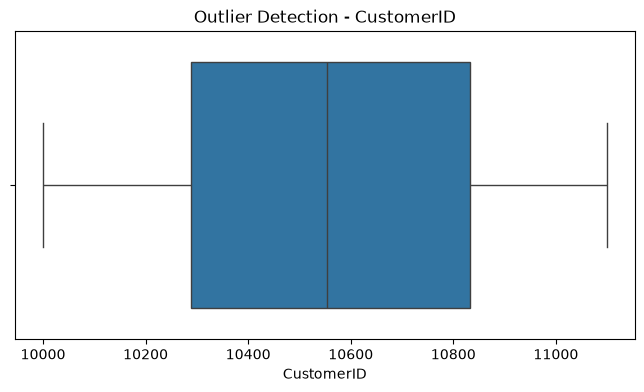

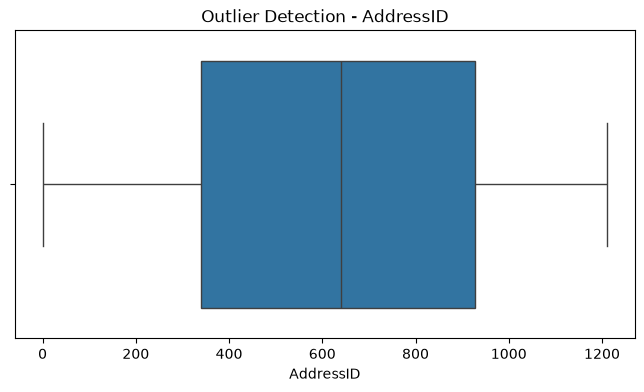

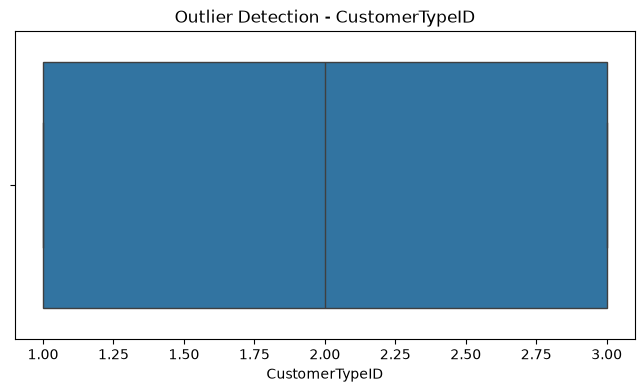

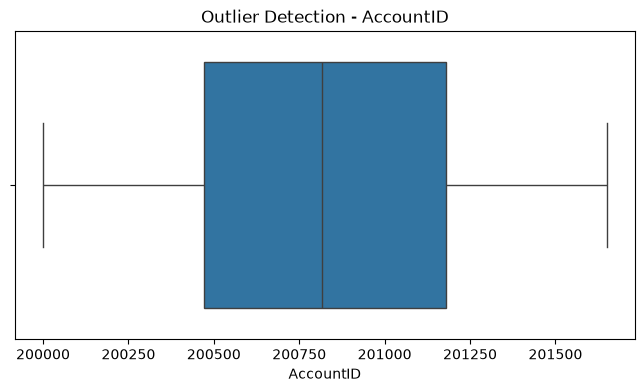

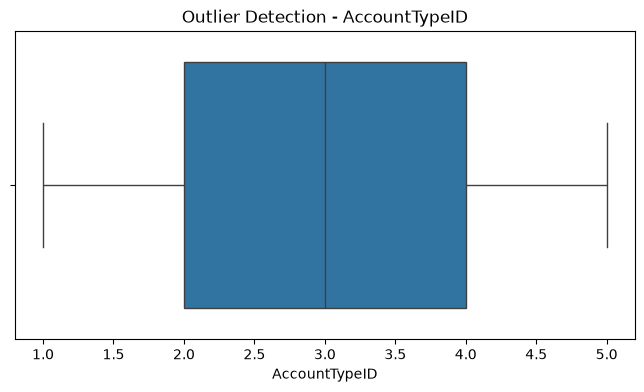

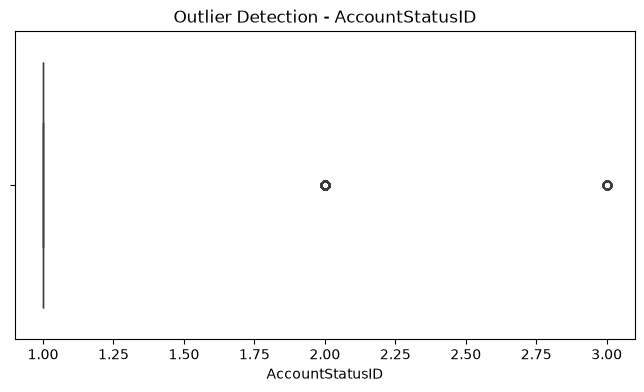

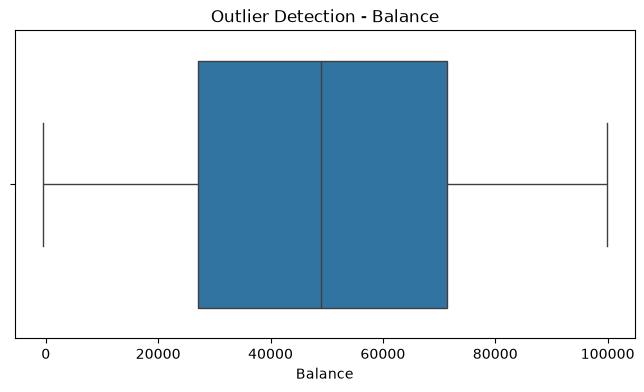

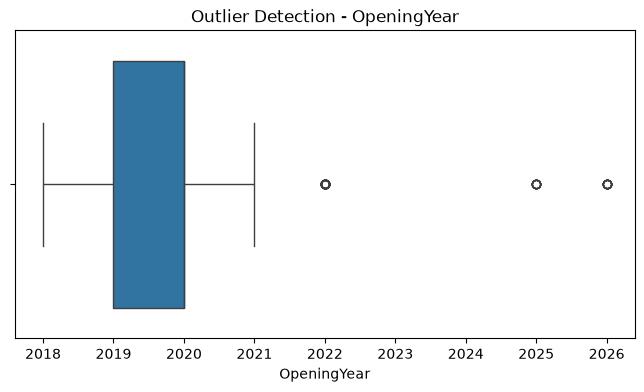

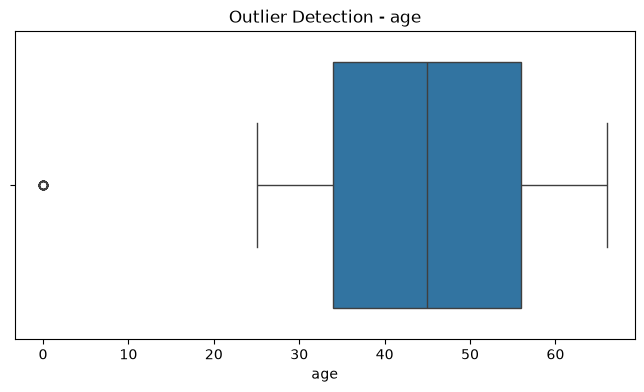

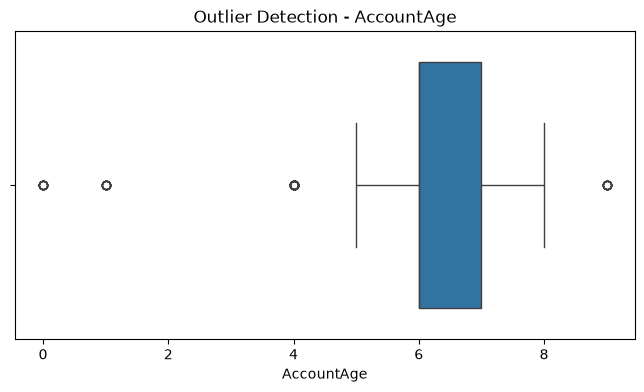

In [13]:
numeric_cols = master.select_dtypes(include=["number"]).columns

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=master[col])

    plt.title(f"Outlier Detection - {col}")

    plt.show()

Customer Type Distribution


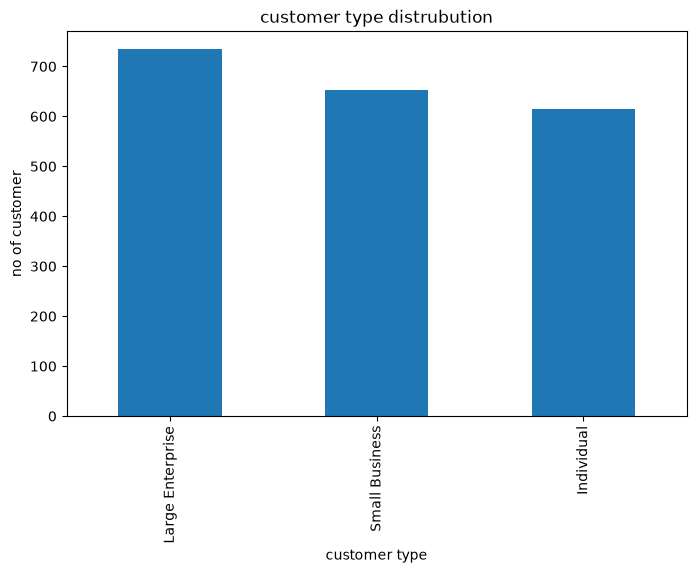

In [15]:
plt.figure(figsize=(8,5))

master["CustomerType"].value_counts().plot(kind="bar")
plt.xlabel("customer type")
plt.ylabel("no of customer")
plt.title("customer type distrubution")

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/customer_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

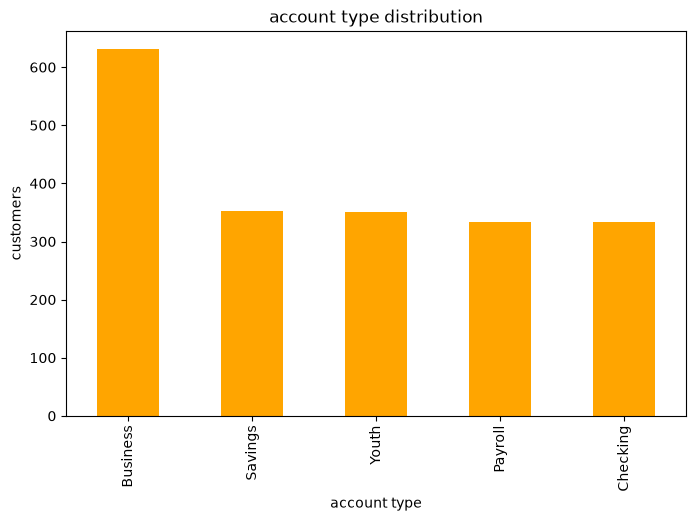

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(8,5))

master["AccountType"].value_counts().plot(kind="bar",color="orange")

plt.xlabel("account type")
plt.ylabel("customers")
plt.title("account type distribution")
plt.show()
plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/account_type_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

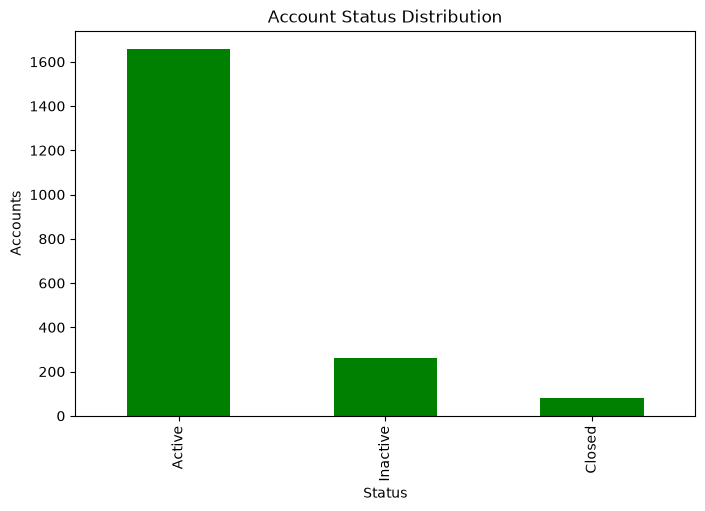

In [17]:
plt.figure(figsize=(8,5))

master["AccountStatus"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Account Status Distribution")
plt.xlabel("Status")
plt.ylabel("Accounts")
plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/account_status_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


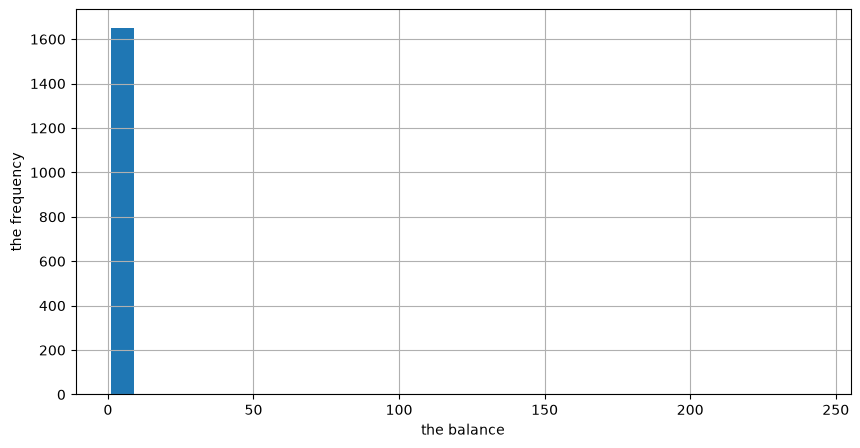

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(10,5))

master["Balance"].value_counts().hist(bins=30)
plt.xlabel("the balance")
plt.ylabel("the frequency")
plt.show()
plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/balance_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
master["City"].unique()

<StringArray>
[        'Aurora',           'Saco',       'Carlsbad',      'Grapevine',
      'Opelousas',         'Garner',       'Westmont',       'Oak Lawn',
     'Zanesville',          'Selma',
 ...
 'Eagle Mountain',         'Edmond',       'Hartford',         'Duarte',
       'Ferndale',    'Thomasville',  'Warner Robins',      'Henderson',
     'San Angelo', 'Bonita Springs']
Length: 577, dtype: str

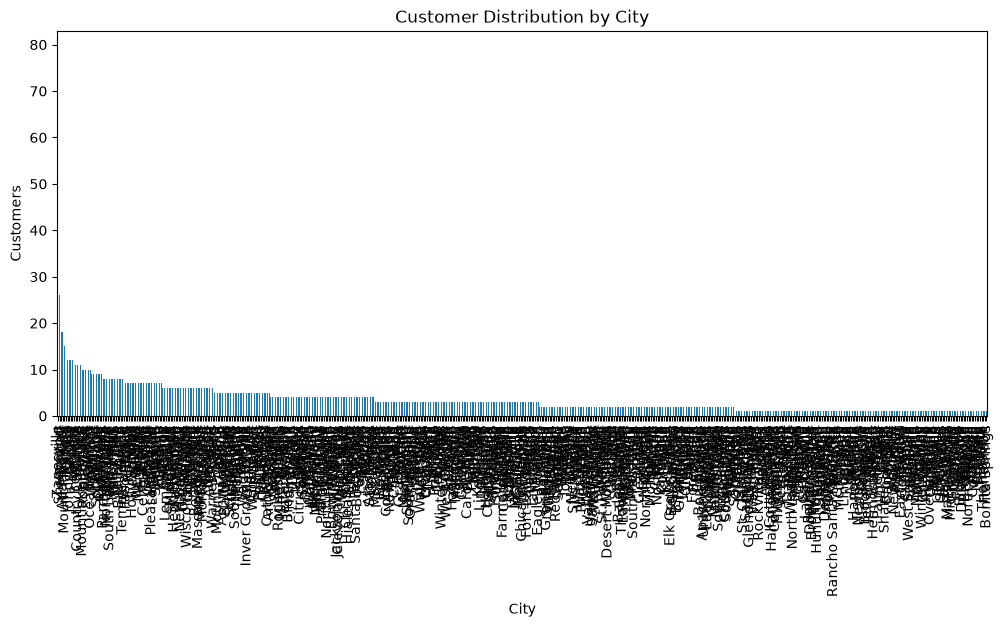

In [21]:
plt.figure(figsize=(12,5))

master["City"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Distribution by City")
plt.xlabel("City")
plt.ylabel("Customers")

plt.xticks(rotation=90)

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/customer_distribution_by_city.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
master["Country"].value_counts()master["Country"] = (
    master["Country"]
    .str.strip()      # Remove leading/trailing spaces
    .str.title()      # Standardize capitalization
)

Country
United States    1979
UnitedcStates       5
United Staes        4
United Slates       4
United StateR       3
Unitd States        3
Pnited States       1
United StXtes       1
United State        1
Name: count, dtype: int64

In [24]:
master["Country"] = (
    master["Country"]
    .str.strip()      # Remove leading/trailing spaces
    .str.title()      # Standardize capitalization
)

In [27]:
country_mapping = {
    "Unitedstates": "United States",
    "United State": "United States",
    "United Stater": "United States",
    "Unitd States": "United States",
    "United Stxtes": "United States",
    "Pnited States": "United States",
    "Unitedcstates":"United States",
    "United Staes":"United States",
    "United Slates":"United States",
    
}

master["Country"] = master["Country"].replace(country_mapping)

In [28]:
master["Country"].value_counts()

Country
United States    2001
Name: count, dtype: int64

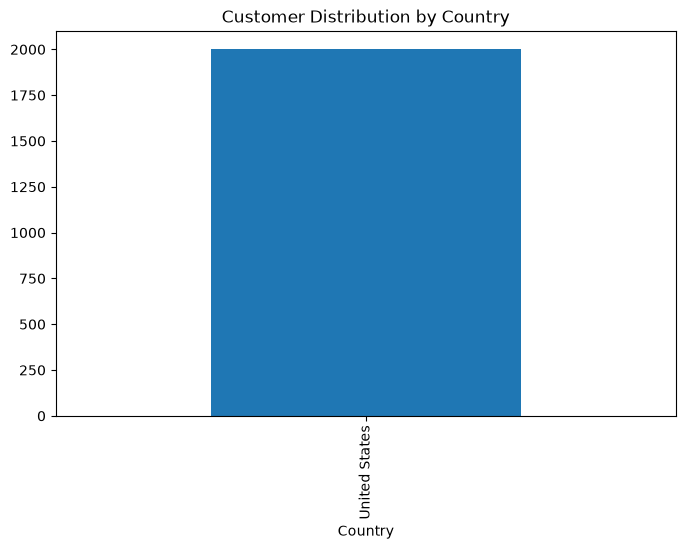

In [31]:
plt.figure(figsize=(8,5))
master["Country"].value_counts()
master["Country"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Distribution by Country")
plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/distribution_country.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

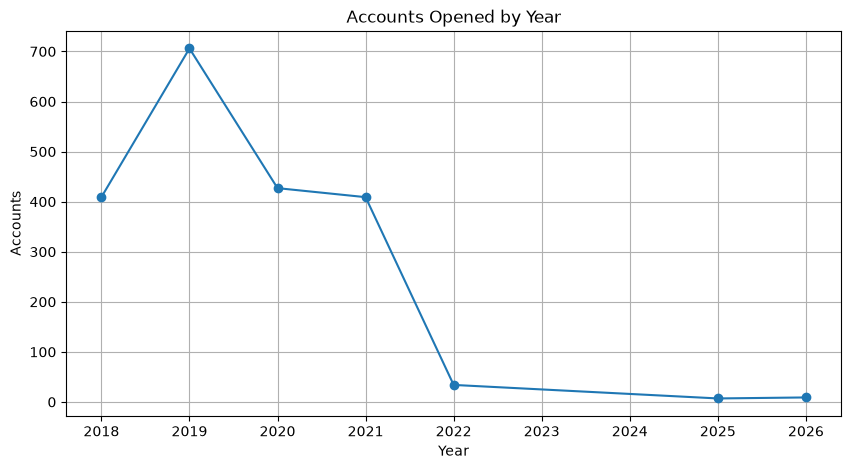

In [30]:
master["OpeningDate"] = pd.to_datetime(master["OpeningDate"])

master["OpeningYear"] = master["OpeningDate"].dt.year

plt.figure(figsize=(10,5))

master["OpeningYear"].value_counts().sort_index().plot(
    marker="o"
)

plt.title("Accounts Opened by Year")
plt.xlabel("Year")
plt.ylabel("Accounts")

plt.grid(True)

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/account_opened_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
master["DateOfBirth"] = pd.to_datetime(
    master["DateOfBirth"],
    errors="coerce"
)

In [33]:
today=pd.Timestamp.today()
master["DateOfBirth"]=pd.to_datetime(master["DateOfBirth"])
master["age"]=((today-master["DateOfBirth"]).dt.days//365)


In [41]:
master["age"]

0       52
1       52
2       63
3       62
4       60
        ..
1996    45
1997    28
1998    28
1999    46
2000    53
Name: age, Length: 2001, dtype: int64

In [54]:
master["age"] = master["age"].replace(0, np.nan)

In [55]:
# Fill missing ages with the median
master["age"] = master["age"].fillna(master["age"].median())

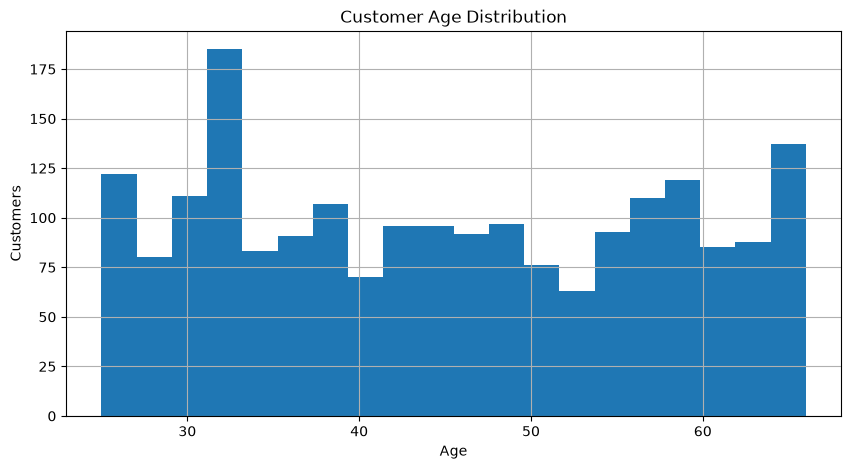

In [56]:
plt.figure(figsize=(10,5))

master["age"].hist(
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/customer_age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

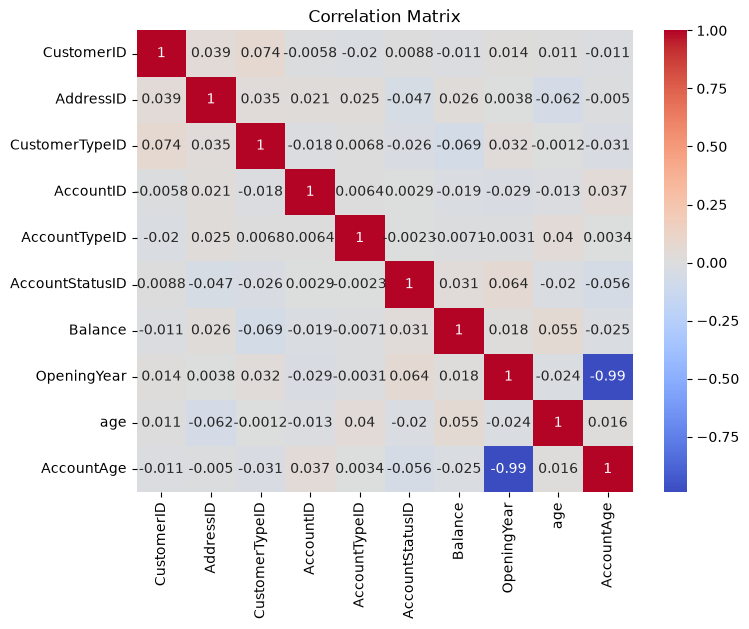

In [57]:
numeric = master.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
master["OpeningDate"]

0      2021-05-25
1      2021-12-12
2      2019-01-26
3      2019-01-26
4      2021-04-07
          ...    
1996   2019-01-26
1997   2018-08-11
1998   2021-11-15
1999   2018-01-07
2000   2019-01-26
Name: OpeningDate, Length: 2001, dtype: datetime64[us]

In [59]:
master["OpeningDate"] = pd.to_datetime(
    master["OpeningDate"],
    errors="coerce"
)

master["AccountAge"] = (
    (today - master["OpeningDate"]).dt.days / 365.25
).round().astype("Int64")

In [60]:
master.head(6)

,CustomerID,FirstName,LastName,DateOfBirth,AddressID,CustomerTypeID,Street,City,Country,CustomerType,AccountID,AccountTypeID,AccountStatusID,Balance,OpeningDate,AccountType,AccountStatus,LoanStatus,OpeningYear,age,AccountAge
0,10832,Nyla,Aguirre,1974-02-07,881,1,Columbia Square,Aurora,United States,Individual,200833.0,2.0,1.0,94714.260,2021-05-25,Savings,Active,Active,2021,52.0,5
1,10832,Nyla,Aguirre,1974-02-07,881,1,Columbia Square,Aurora,United States,Individual,200904.0,4.0,1.0,84891.940,2021-12-12,Business,Active,Active,2021,52.0,5
2,10983,Elfreda,Battle,1963-02-01,958,2,Coventry,Saco,United States,Small Business,200817.5,3.0,1.0,48937.705,2019-01-26,Business,Active,Active,2019,63.0,7
3,10837,Angelena,Harrington,1964-03-25,86,3,Wilson,Carlsbad,United States,Large Enterprise,200817.5,3.0,1.0,48937.705,2019-01-26,Business,Active,Active,2019,62.0,7
4,10107,Remona,Glass,1965-09-16,595,1,Koret,Grapevine,United States,Individual,200191.0,2.0,1.0,64668.960,2021-04-07,Savings,Active,Active,2021,60.0,5
5,10107,Remona,Glass,1965-09-16,595,1,Koret,Grapevine,United States,Individual,200882.0,3.0,1.0,87535.780,2021-01-06,Payroll,Active,Active,2021,60.0,6


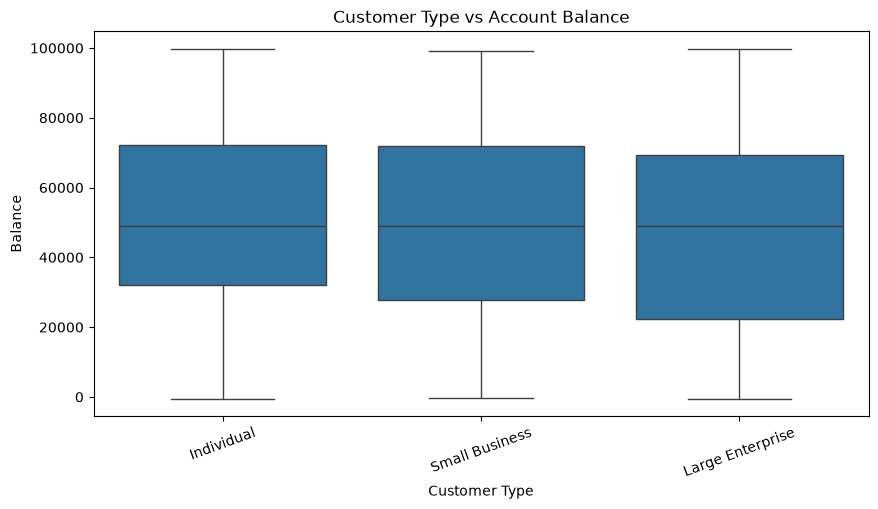

In [61]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="CustomerType",
    y="Balance",
    data=master
)

plt.title("Customer Type vs Account Balance")
plt.xlabel("Customer Type")
plt.ylabel("Balance")

plt.xticks(rotation=20)

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/cust_type_vs_balance.png", dpi=300, bbox_inches="tight")
plt.show()

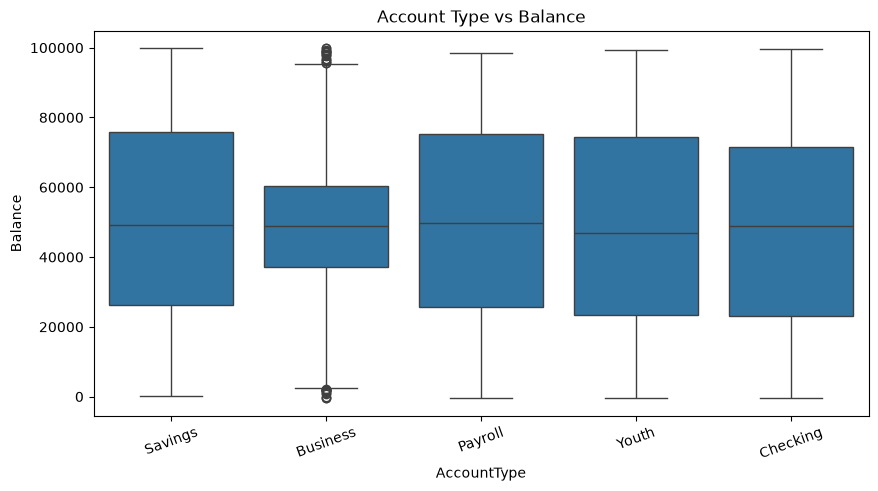

In [62]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="AccountType",
    y="Balance",
    data=master
)

plt.title("Account Type vs Balance")

plt.xticks(rotation=20)


plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/accoutype_vs_balance.png", dpi=300, bbox_inches="tight")
plt.show()

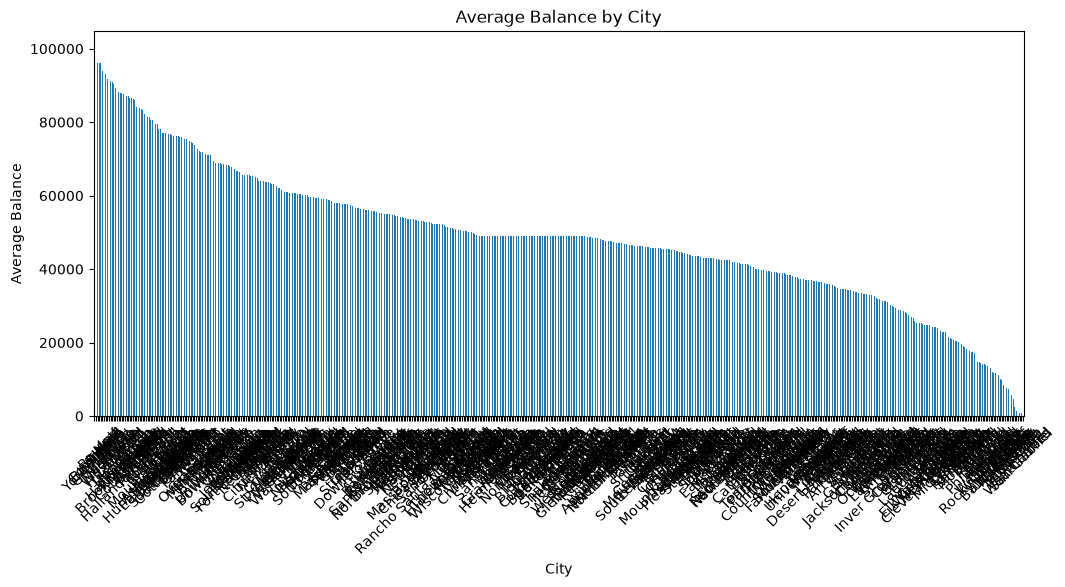

In [63]:
city_balance = (
    master.groupby("City")["Balance"]
          .mean()
          .sort_values(ascending=False)
)


plt.figure(figsize=(12,5))

city_balance.plot(kind="bar")

plt.title("Average Balance by City")
plt.xlabel("City")
plt.ylabel("Average Balance")

plt.xticks(rotation=45)

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/city_balance.png", dpi=300)

plt.show()

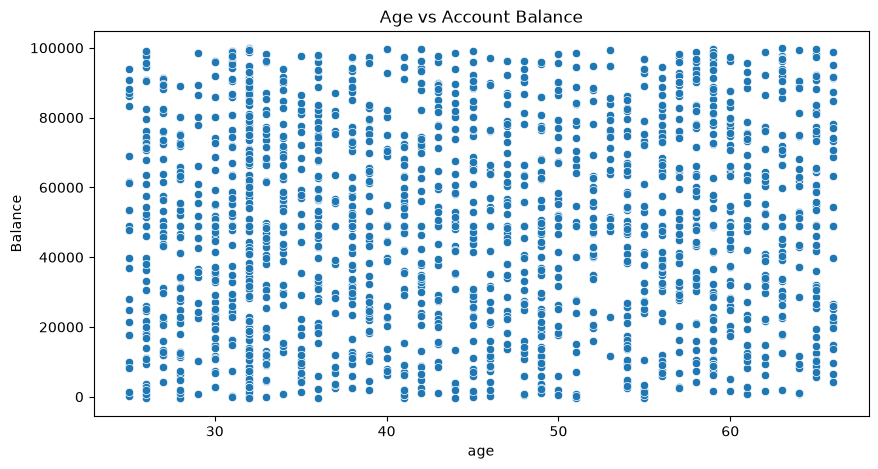

In [64]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=master,
    x="age",
    y="Balance"
)

plt.title("Age vs Account Balance")

plt.savefig("/home/student/308/mlm/AI-Banking-Financial-Intelligence-Platform/modules/Module_01_Data_Analytics/visuals/age_balance.png", dpi=300)

plt.show()

In [66]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=loans,
    x="PrincipalAmount",
    y="InterestRate"
)

plt.title("Loan Amount vs Interest Rate")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/loan_interest.png", dpi=300)

plt.show()

NameError: name 'loans' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
transaction_analysis = transactions.merge(
    transaction_types,
    on="TransactionTypeID",
    how="left"
)

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=transaction_analysis,
    x="TypeName",
    y="Amount"
)

plt.title("Transaction Type vs Amount")

plt.xticks(rotation=20)

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/transactiontype_amount.png", dpi=300)

plt.show()

In [ ]:
master["OpeningYear"] = pd.to_datetime(
    master["OpeningDate"]
).dt.year

opening = pd.crosstab(
    master["OpeningYear"],
    master["CustomerType"]
)

opening.plot(figsize=(12,6))

plt.title("Account Openings by Customer Type")

plt.savefig("/mnt/Project/mlm/AI_Banking_Financial_Intelligence/visuals/opening_customer.png", dpi=300)

plt.show()

In [67]:
print("="*70)
print("MODULE 1 COMPLETED")
print("="*70)

print(f"Number of Customers : {master['CustomerID'].nunique()}")
print(f"Number of Accounts  : {master['AccountID'].nunique()}")
print(f"Average Balance     : {master['Balance'].mean():,.2f}")
print(f"Maximum Balance     : {master['Balance'].max():,.2f}")
print(f"Minimum Balance     : {master['Balance'].min():,.2f}")

MODULE 1 COMPLETED
Number of Customers : 1100
Number of Accounts  : 1652
Average Balance     : 48,899.69
Maximum Balance     : 99,828.98
Minimum Balance     : -486.68


module 1 conclution


-the database dataset are merged in master dataset
-done univate analysis,bivariate and multivariate analysis
-the graphs are stored and analysis